# Numerical validation of the model

This notebook compares five configurations of the model:

- baseline: $\Delta t=0.05$, $t_{\mathrm{stab}}=0$, and one deformation attempt;
- $t_{\mathrm{stab}}=120$;
- ten deformation attempts;
- $\Delta t=0.025$;
- triangular initial condition.

The initial goal is to compare the temporal evolution of the simulations.

All time series will be expressed in physical time,

$$
t = n_{\mathrm{step}}\Delta t,
$$

and each realization will be treated as an independent statistical replicate.

## Import libraries

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load and inspect data

The individual output files were previously consolidated into one Parquet dataset for each simulation condition.

Two datasets are loaded:

- global order parameters;
- motion observables.

The temporal step is converted into physical time using the value of $\Delta t$ associated with each condition.

In [2]:
# Directory containing the five simulation conditions.
DATA_DIR = Path("./validation_data")

conditions = {
    "baseline": {
        "folder": "t_stab=0",
        "delta_t": 0.05,
    },
    "t_stab=120": {
        "folder": "t_stab=120",
        "delta_t": 0.05,
    },
    "def=10": {
        "folder": "def=10",
        "delta_t": 0.05,
    },
    "delta_t=0.025": {
        "folder": "delta_t=0_025",
        "delta_t": 0.025,
    },
    "triangular": {
        "folder": "triangular",
        "delta_t": 0.05,
    },
}

In [3]:
# Define the paths for the processed datasets
PROCESSED_FILES = {
    "order_parameters": (
        Path("processed")
        / "order_parameters"
        / "order_parameters.parquet"
    ),
    "motion": (
        Path("processed")
        / "motion"
        / "motion.parquet"
    ),
}


# Function to load one processed dataset for one simulation condition
def load_processed_dataset(
    data_directory,
    condition_name,
    condition_data,
    dataset_name,
):
    """Load one processed dataset for one simulation condition."""

    parquet_path = (
        data_directory
        / condition_data["folder"]
        / PROCESSED_FILES[dataset_name]
    )

    data = pd.read_parquet(parquet_path).copy()

    # Add the condition name, delta_t, and physical time to the dataset
    data["condition"] = condition_name
    data["delta_t"] = condition_data["delta_t"]
    data["physical_time"] = (
        data["step"] * data["delta_t"]
    )

    return data

In [4]:
# Load order parameters datasets for all simulation conditions
order_data = pd.concat(
    [
        load_processed_dataset(
            DATA_DIR,
            condition_name,
            condition_data,
            "order_parameters",
        )
        for condition_name, condition_data
        in conditions.items()
    ],
    ignore_index=True,
)

In [5]:
# Load motion datasets for all simulation conditions
motion_data = pd.concat(
    [
        load_processed_dataset(
            DATA_DIR,
            condition_name,
            condition_data,
            "motion",
        )
        for condition_name, condition_data
        in conditions.items()
    ],
    ignore_index=True,
)

In [6]:
# Sort the datasets by condition, seed, and physical time
sort_columns = [
    "condition",
    "seed",
    "physical_time",
]

order_data = (
    order_data
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

motion_data = (
    motion_data
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

In [7]:
# Check the columns of the datasets
print("Order-parameter columns:")
print(order_data.columns.tolist())

print("\nMotion columns:")
print(motion_data.columns.tolist())

Order-parameter columns:
['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'initial_fraction_elongated', 'force', 'nematic', 'polar', 'nematic_2', 'polar_2', 'fraction_elongated', 'condition', 'delta_t', 'physical_time']

Motion columns:
['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'initial_fraction_elongated', 'force', 'mean_step_displacement', 'mean_squared_step_displacement', 'p95_step_displacement', 'msd_t0', 'condition', 'delta_t', 'physical_time']


## Elongated fraction for individual realizations

We first inspect the elongated fraction of every realization separately.

In [13]:
# Define labels and colors for the simulation conditions
condition_labels = {
    "baseline": r"Baseline ($t_{\mathrm{stab}}=0$)",
    "t_stab=120": r"$t_{\mathrm{stab}}=120$",
    "def=10": "10 deformation attempts",
    "delta_t=0.025": r"$\Delta t=0.025$",
    "triangular": "Triangular initial condition",
}

condition_colors = {
    "baseline": "tab:blue",
    "t_stab=120": "tab:orange",
    "def=10": "tab:green",
    "delta_t=0.025": "tab:red",
    "triangular": "tab:purple",
}

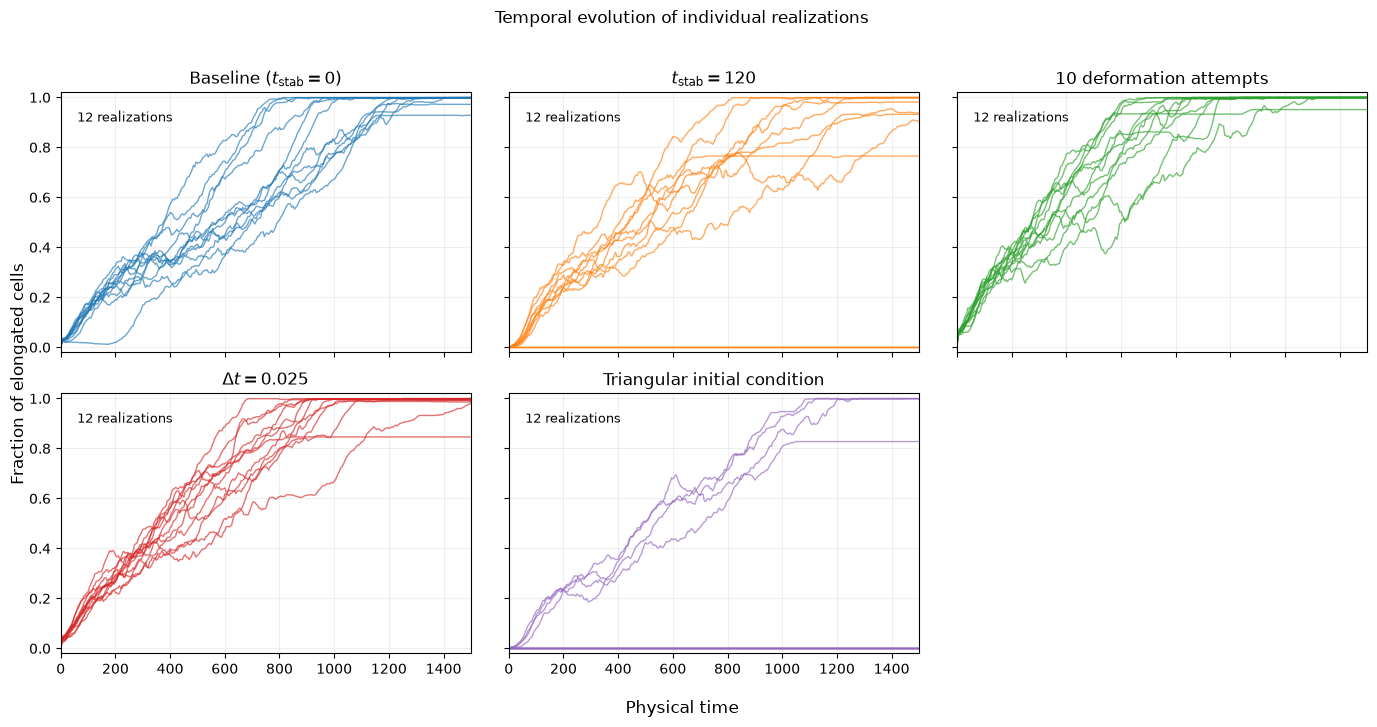

In [14]:
# Create a 2x3 grid of subplots to visualize the temporal evolution of individual realizations
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(14, 7),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()

# Plot the temporal evolution of individual realizations for each simulation condition
for ax, condition_name in zip(
    axes,
    conditions.keys(),
):
    # Filter the order_data for the current condition
    condition_data = order_data[
        order_data["condition"] == condition_name
    ]

    # Plot the temporal evolution of individual realizations for the current condition
    for seed, realization_data in condition_data.groupby("seed"):

        realization_data = realization_data.sort_values(
            "physical_time"
        )

        ax.plot(
            realization_data["physical_time"],
            realization_data["fraction_elongated"],
            color=condition_colors[condition_name],
            linewidth=1.0,
            alpha=0.65,
        )

    number_of_realizations = (
        condition_data["seed"].nunique()
    )

    ax.set_title(
        condition_labels[condition_name]
    )

    ax.text(
        0.04,
        0.93,
        f"{number_of_realizations} realizations",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

    ax.set_xlim(0, 1500)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.2)

# The sixth panel is not required.
axes[-1].axis("off")

fig.supxlabel("Physical time")
fig.supylabel("Fraction of elongated cells")

fig.suptitle(
    "Temporal evolution of individual realizations",
    y=1.02,
)

fig.tight_layout()

root = Path(".")
folder = root / "figures"
folder.mkdir(parents=True, exist_ok=True)
plt.savefig(
    root / folder / "temporal_evolution_individual_realizations.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()